In [ ]:
# Gerekli kütüphanelerin içe aktarılması

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


#Veri Seti 1: California Housing

In [ ]:
# California Housing veri seti OpenML'den çekiliyor

data = fetch_openml(name="house_prices", version=1, as_frame=True)

df = data.frame
print(f"Veri seti boyutu: {df.shape}")
df.head()

Veri seti boyutu: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


###  Keşifsel Veri Analizi (EDA)

In [ ]:
# Veri setinin genel bilgileri
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Temel istatistiksel özet
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
# Eksik değerlerin kontrolü
missing = df.isnull().sum()
print("Eksik değer sayıları:")
print(missing[missing > 0])

Eksik değer sayıları:
LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


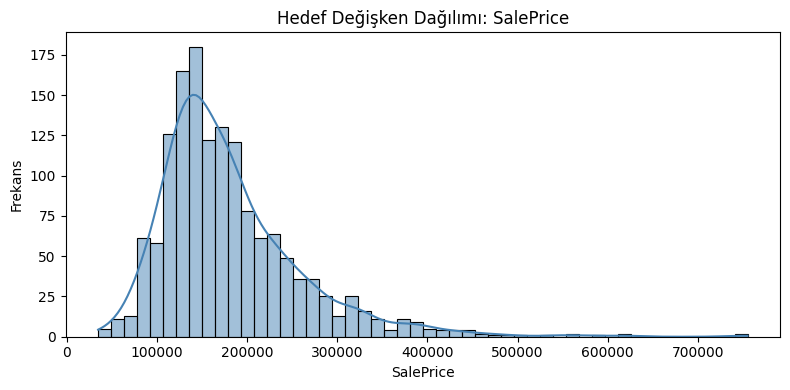

In [ ]:
# Hedef değişkenin dağılımı
plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], bins=50, kde=True, color='steelblue')
plt.title('Hedef Değişken Dağılımı: SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

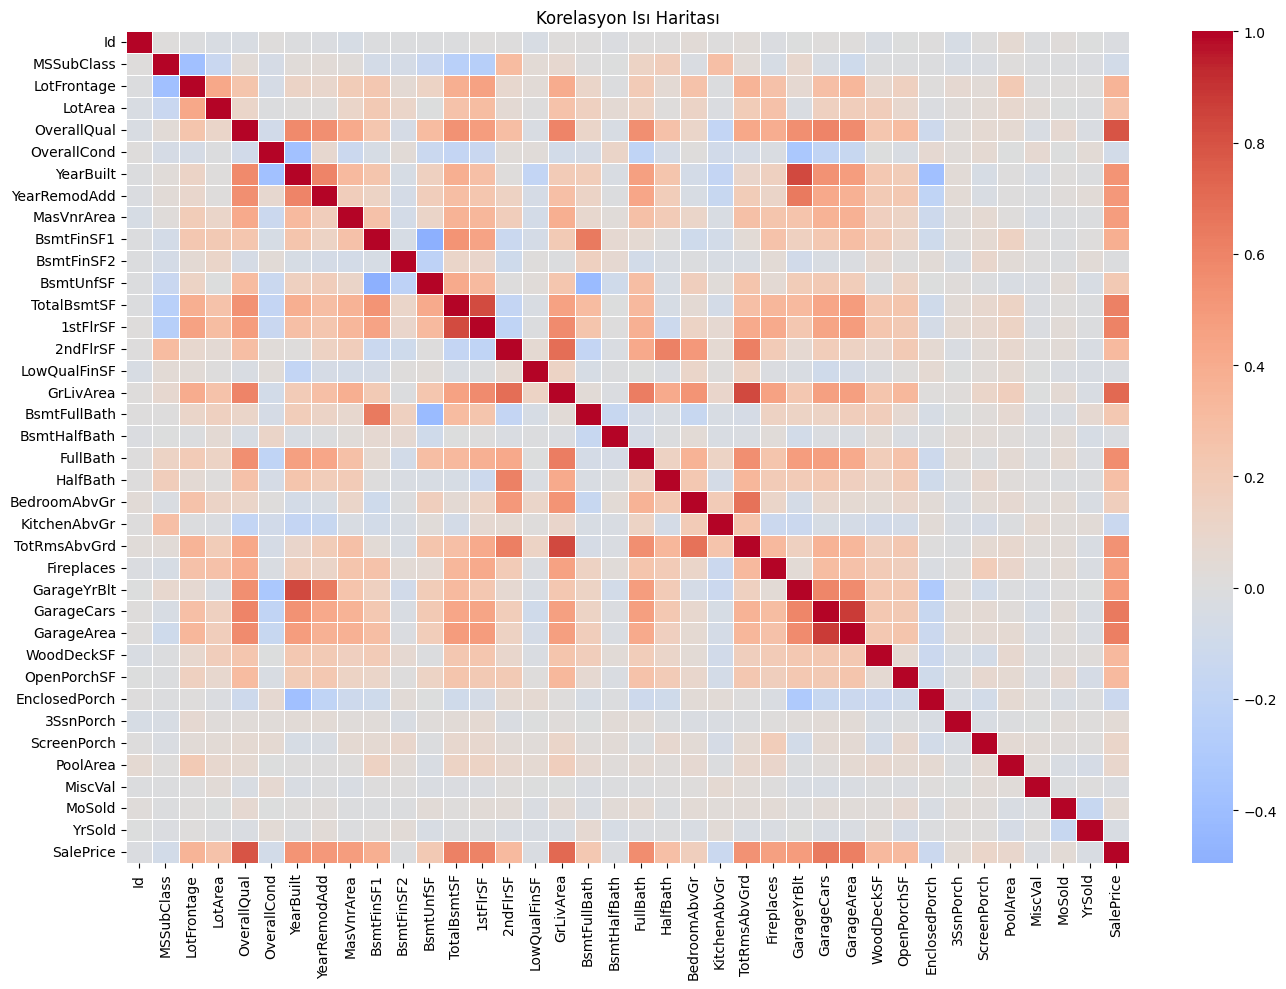

In [ ]:
# Sayısal değişkenler arası korelasyon ısı haritası
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numerical_df.corr(), cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Korelasyon Isı Haritası')
plt.tight_layout()
plt.show()

### Veri Ön İşleme

In [ ]:
# Sayısal sütunlardaki eksik değerler medyan ile dolduruluyor
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Kategorik sütunlardaki eksik değerler mod ile dolduruluyor
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

print(f"Eksik değer kaldı mı: {df.isnull().sum().sum()}")

Eksik değer kaldı mı: 0


In [ ]:
# Kategorik değişkenler one-hot encoding ile sayısala dönüştürülüyor
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Encoding sonrası boyut: {df_encoded.shape}")

Encoding sonrası boyut: (1460, 247)


In [ ]:
# Hedef değişkendeki aykırı değerler IQR yöntemiyle tespit ediliyor
Q1 = df_encoded['SalePrice'].quantile(0.25)
Q3 = df_encoded['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_encoded[(df_encoded['SalePrice'] < lower) | (df_encoded['SalePrice'] > upper)]
print(f"Tespit edilen aykırı değer sayısı: {len(outliers)}")

Tespit edilen aykırı değer sayısı: 61


In [ ]:
# Aykırı değerler veri setinden çıkarılıyor
df_encoded = df_encoded[(df_encoded['SalePrice'] >= lower) & (df_encoded['SalePrice'] <= upper)]
print(f"Aykırı değer temizleme sonrası veri boyutu: {df_encoded.shape}")

Aykırı değer temizleme sonrası veri boyutu: (1399, 247)


In [ ]:
# Özellikler (X) ve hedef değişken (y) ayrılıyor
X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']

print(f"X boyutu: {X.shape}")
print(f"y boyutu: {y.shape}")

X boyutu: (1399, 246)
y boyutu: (1399,)


#### Train/Test Split

In [ ]:
# Veri %80 eğitim, %20 test olarak ayrılıyor
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Eğitim seti: {X_train.shape}")
print(f"Test seti: {X_test.shape}")

Eğitim seti: (1119, 246)
Test seti: (280, 246)


In [ ]:
# Özellikler StandardScaler ile ölçeklendiriliyor
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklendirme tamamlandı.")

Ölçeklendirme tamamlandı.


### Model Eğitimi

In [ ]:
# Baseline model olarak DummyRegressor kullanılıyor (her zaman ortalama tahmin eder)
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

print(" Baseline model eğitildi.")

 Baseline model eğitildi.


In [ ]:
# Lineer regresyon modeli eğitiliyor
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print( "Lineer regresyon modeli eğitildi.")

Lineer regresyon modeli eğitildi.


In [ ]:
# Baseline ve lineer regresyon metrikleri hesaplanıyor
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print()
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_1 = []
results_1.append(evaluate_model(y_test, y_pred_dummy, "Baseline (DummyRegressor)"))
results_1.append(evaluate_model(y_test, y_pred_lr, "Lineer Regresyon"))

  Baseline (DummyRegressor)
  MAE  : 44723.14
  RMSE : 56664.98
  R²   : -0.0095

  Lineer Regresyon
  MAE  : 17308.50
  RMSE : 54916.60
  R²   : 0.0519



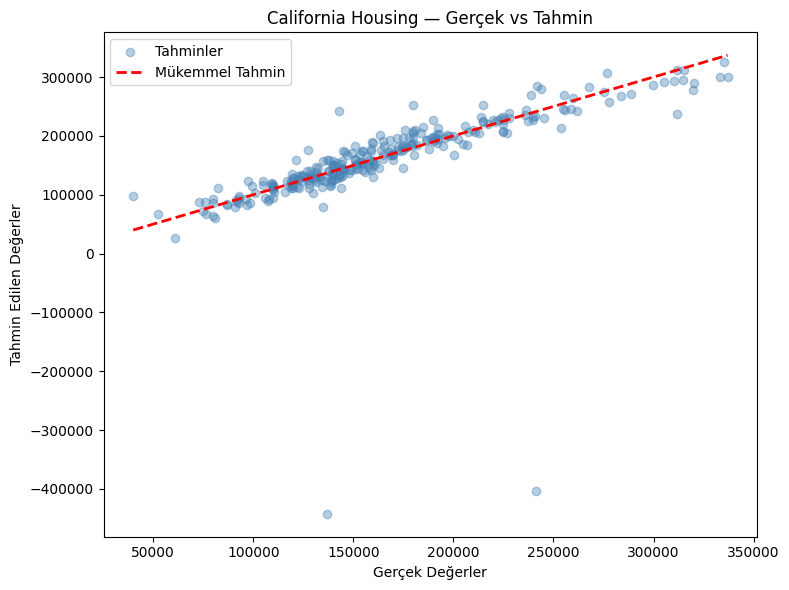

In [ ]:
# Gerçek vs tahmin edilen değerler karşılaştırması
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', label='Tahminler')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Mükemmel Tahmin')
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('California Housing — Gerçek vs Tahmin')
plt.legend()
plt.tight_layout()
plt.show()

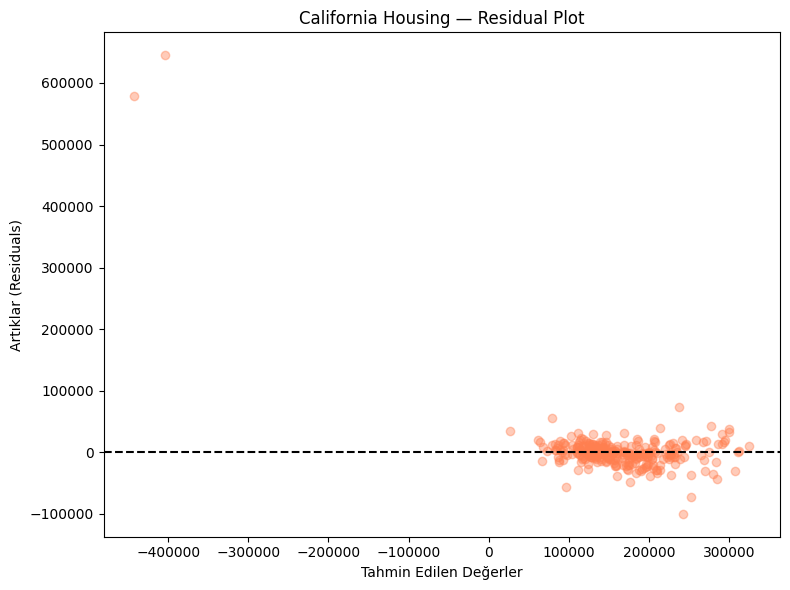

In [ ]:
# Artık (residual) değerlerin dağılımı inceleniyor
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, residuals, alpha=0.4, color='coral')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Artıklar (Residuals)')
plt.title('California Housing — Residual Plot')
plt.tight_layout()
plt.show()

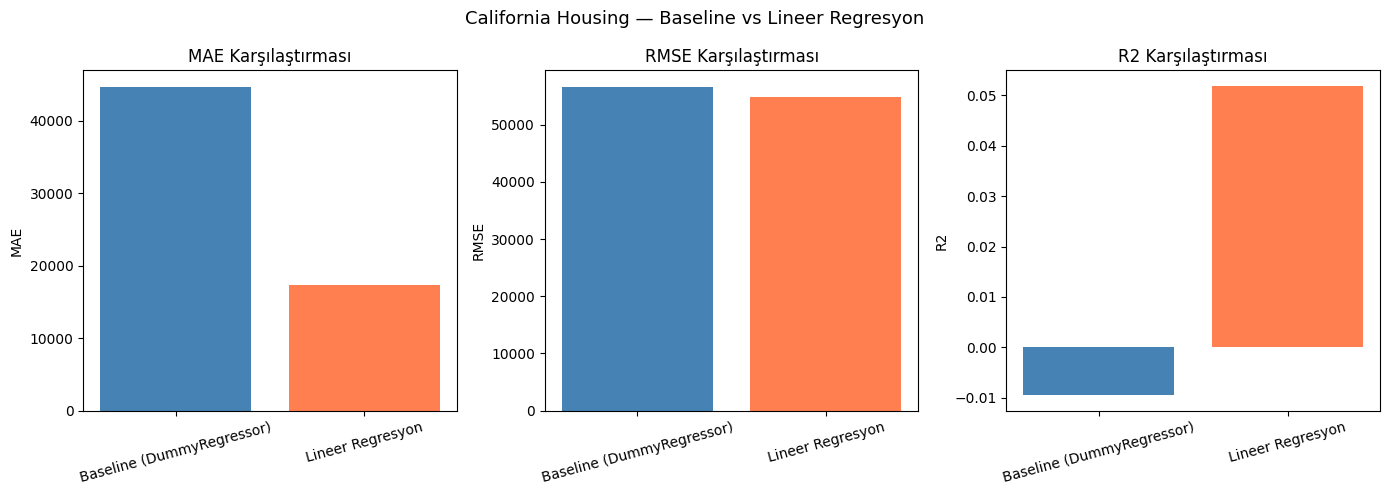

In [ ]:
# Baseline vs Lineer Regresyon metrik karşılaştırması
results_df_1 = pd.DataFrame(results_1)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df_1['model'], results_df_1[metric], color=colors)
    axes[i].set_title(f'{metric} Karşılaştırması')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('California Housing — Baseline vs Lineer Regresyon', fontsize=13)
plt.tight_layout()
plt.show()

### Değerlendirme Notu

**California Housing (Ames Housing) — Sonuç Yorumu**

Lineer Regresyon, Baseline modele kıyasla MAE'yi yaklaşık %61 oranında düşürmüştür
(44.723 → 17.308). Bu, modelin ortalama tahminden anlamlı ölçüde daha iyi çalıştığını gösterir.

Ancak R² değerinin yalnızca 0.05 olması, modelin hedef değişkendeki varyansın
yalnızca %5'ini açıklayabildiğine işaret etmektedir. Bu düşük performansın temel
nedeni veri setinin 79 özellik içermesi ve one-hot encoding sonrası boyutun büyük
ölçüde artmasıdır — lineer regresyon bu kadar geniş ve seyrek özellik uzayında
zorlanmaktadır.

Residual plot'ta sol üst köşedeki aykırı noktalar, bazı tahminlerin negatif değerler
ürettiğini göstermektedir. Bu durum, yüksek boyutlu veri setlerinde lineer regresyonun
sınırlılığını ortaya koymaktadır.

Baseline modelin R²'si negatif (-0.009) çıkmıştır; bu beklenen bir durumdur çünkü
DummyRegressor her örnek için sabit ortalama tahmin yapar.

# Veri Seti 2: Wine Quality

In [ ]:
# Wine Quality veri seti OpenML'den çekiliyor
wine = fetch_openml(name='wine-quality-red', version=1, as_frame=True)

df2 = wine.frame
print(f"Veri seti boyutu: {df2.shape}")
df2.head()

Veri seti boyutu: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,class
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Keşifsel Veri Analizi (EDA)

In [ ]:
# Veri setinin genel bilgileri
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed_acidity         1599 non-null   float64 
 1   volatile_acidity      1599 non-null   float64 
 2   citric_acid           1599 non-null   float64 
 3   residual_sugar        1599 non-null   float64 
 4   chlorides             1599 non-null   float64 
 5   free_sulfur_dioxide   1599 non-null   float64 
 6   total_sulfur_dioxide  1599 non-null   float64 
 7   density               1599 non-null   float64 
 8   pH                    1599 non-null   float64 
 9   sulphates             1599 non-null   float64 
 10  alcohol               1599 non-null   float64 
 11  class                 1599 non-null   category
dtypes: category(1), float64(11)
memory usage: 139.3 KB


In [ ]:
# Temel istatistiksel özet
df2.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [ ]:
# Eksik değerlerin kontrolü
missing2 = df2.isnull().sum()
print("Eksik değer sayıları:")
print(missing2[missing2 > 0])
print(f"\nToplam eksik değer: {df2.isnull().sum().sum()}")

Eksik değer sayıları:
Series([], dtype: int64)

Toplam eksik değer: 0


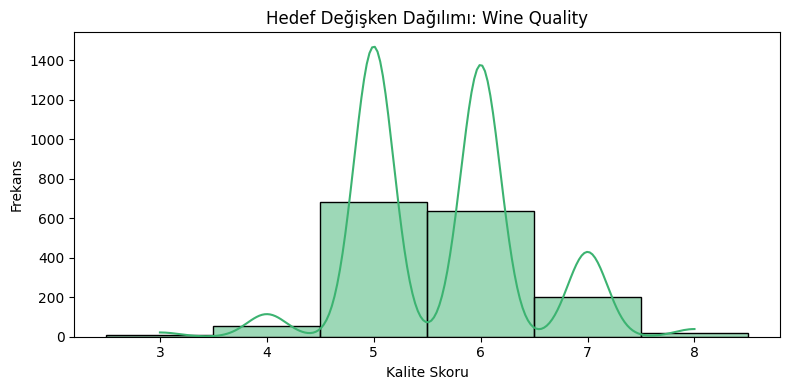

In [ ]:
# Hedef değişkenin dağılımı (kalite skoru)
plt.figure(figsize=(8, 4))
sns.histplot(df2['class'], bins=20, kde=True, color='mediumseagreen')
plt.title('Hedef Değişken Dağılımı: Wine Quality')
plt.xlabel('Kalite Skoru')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

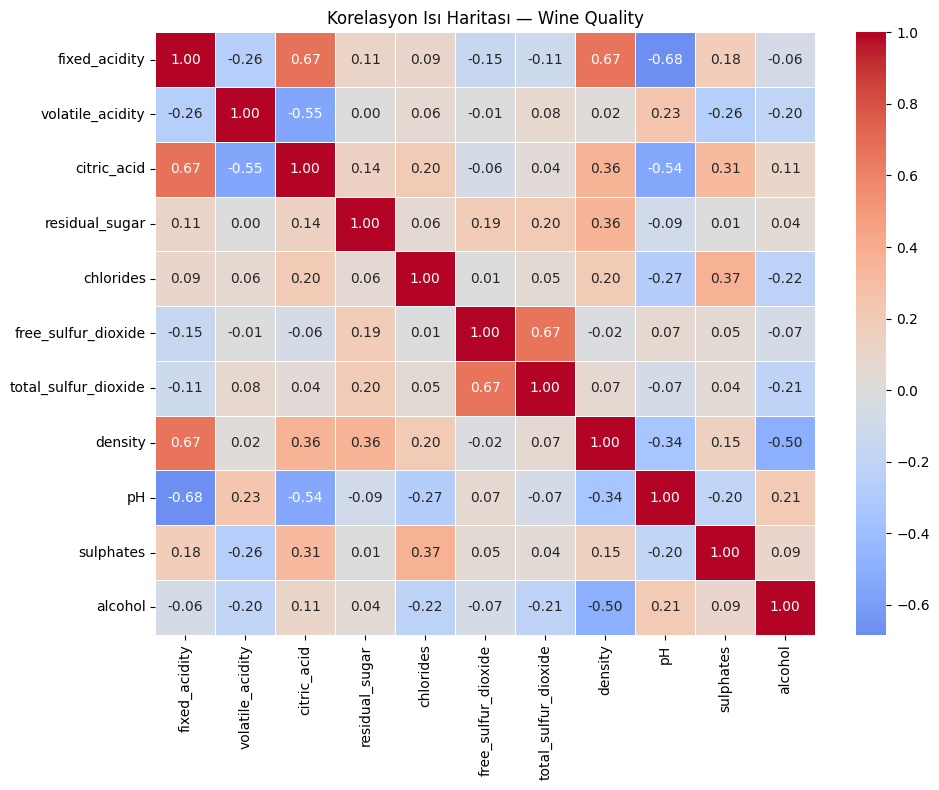

In [ ]:
# Sayısal değişkenler arası korelasyon ısı haritası
numerical_df2 = df2.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df2.corr(), cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5)
plt.title('Korelasyon Isı Haritası — Wine Quality')
plt.tight_layout()
plt.show()

### Veri Ön İşleme

In [ ]:
# Eksik değer yoksa bilgi veriliyor, varsa medyan ile dolduruluyor
if df2.isnull().sum().sum() == 0:
    print(" Eksik değer bulunmuyor.")
else:
    df2 = df2.fillna(df2.median())
    print(" Eksik değerler medyan ile dolduruldu.")

 Eksik değer bulunmuyor.


In [ ]:
# Hedef değişken sayısala dönüştürülüyor
df2['class'] = pd.to_numeric(df2['class'], errors='coerce')
print(f"Hedef değişken tipi: {df2['class'].dtype}")

Hedef değişken tipi: int64


In [ ]:
# Hedef değişkendeki aykırı değerler IQR yöntemiyle tespit ediliyor
Q1_w = df2['class'].quantile(0.25)
Q3_w = df2['class'].quantile(0.75)
IQR_w = Q3_w - Q1_w

lower_w = Q1_w - 1.5 * IQR_w
upper_w = Q3_w + 1.5 * IQR_w

outliers_w = df2[(df2['class'] < lower_w) | (df2['class'] > upper_w)]
print(f"Tespit edilen aykırı değer sayısı: {len(outliers_w)}")

Tespit edilen aykırı değer sayısı: 28


In [ ]:
# Aykırı değerler veri setinden çıkarılıyor
df2 = df2[(df2['class'] >= lower_w) & (df2['class'] <= upper_w)]
print(f"Temizleme sonrası veri boyutu: {df2.shape}")

Temizleme sonrası veri boyutu: (1571, 12)


In [ ]:
# Özellikler (X) ve hedef değişken (y) ayrılıyor
X2 = df2.drop(columns=['class'])
y2 = df2['class']

print(f"X boyutu: {X2.shape}")
print(f"y boyutu: {y2.shape}")

X boyutu: (1571, 11)
y boyutu: (1571,)


#### Train/Test Split

In [ ]:
# Veri %80 eğitim, %20 test olarak ayrılıyor
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print(f"Eğitim seti: {X2_train.shape}")
print(f"Test seti: {X2_test.shape}")

Eğitim seti: (1256, 11)
Test seti: (315, 11)


In [ ]:
# Özellikler StandardScaler ile ölçeklendiriliyor
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print(" Ölçeklendirme tamamlandı.")

 Ölçeklendirme tamamlandı.


### Model Eğitimi

In [ ]:
# Baseline model olarak DummyRegressor kullanılıyor
dummy2 = DummyRegressor(strategy='mean')
dummy2.fit(X2_train_scaled, y2_train)
y2_pred_dummy = dummy2.predict(X2_test_scaled)

print(" Baseline model eğitildi.")

 Baseline model eğitildi.


In [ ]:
# Lineer regresyon modeli eğitiliyor
lr2 = LinearRegression()
lr2.fit(X2_train_scaled, y2_train)
y2_pred_lr = lr2.predict(X2_test_scaled)

print("Lineer regresyon modeli eğitildi.")

Lineer regresyon modeli eğitildi.


In [ ]:
# Baseline ve lineer regresyon metrikleri hesaplanıyor
results_2 = []
results_2.append(evaluate_model(y2_test, y2_pred_dummy, "Baseline (DummyRegressor)"))
results_2.append(evaluate_model(y2_test, y2_pred_lr, "Lineer Regresyon"))

  Baseline (DummyRegressor)
  MAE  : 0.67
  RMSE : 0.77
  R²   : -0.0076

  Lineer Regresyon
  MAE  : 0.50
  RMSE : 0.61
  R²   : 0.3787



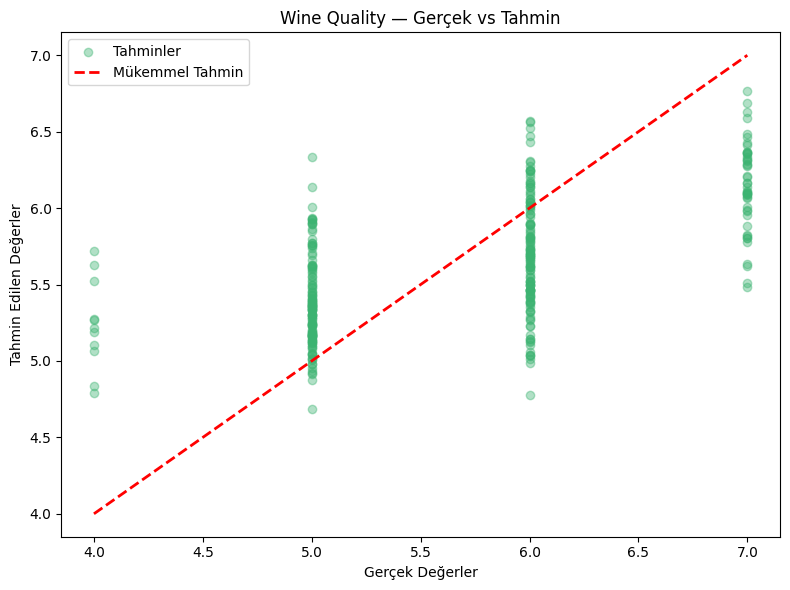

In [ ]:
# Gerçek vs tahmin edilen değerler karşılaştırması
plt.figure(figsize=(8, 6))
plt.scatter(y2_test, y2_pred_lr, alpha=0.4, color='mediumseagreen', label='Tahminler')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()],
         'r--', linewidth=2, label='Mükemmel Tahmin')
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('Wine Quality — Gerçek vs Tahmin')
plt.legend()
plt.tight_layout()
plt.show()

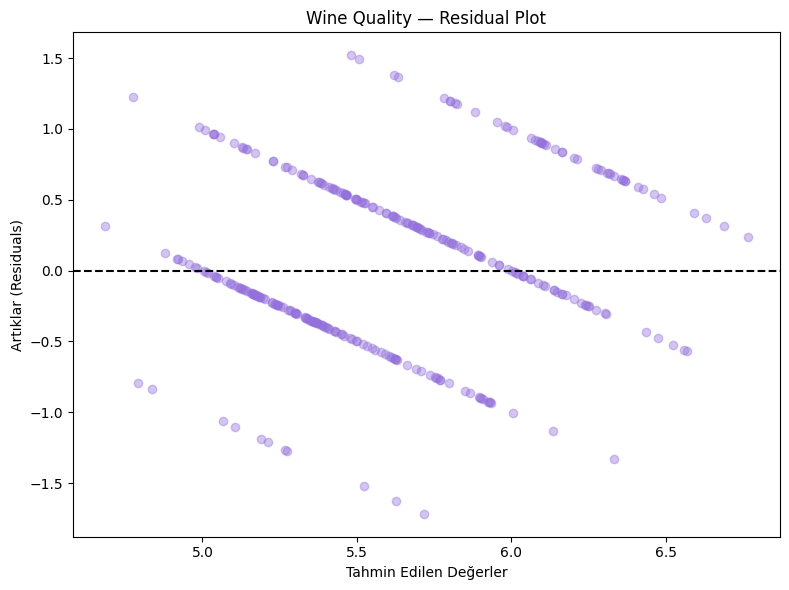

In [ ]:
# Artık (residual) değerlerin dağılımı inceleniyor
residuals2 = y2_test - y2_pred_lr

plt.figure(figsize=(8, 6))
plt.scatter(y2_pred_lr, residuals2, alpha=0.4, color='mediumpurple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Artıklar (Residuals)')
plt.title('Wine Quality — Residual Plot')
plt.tight_layout()
plt.show()

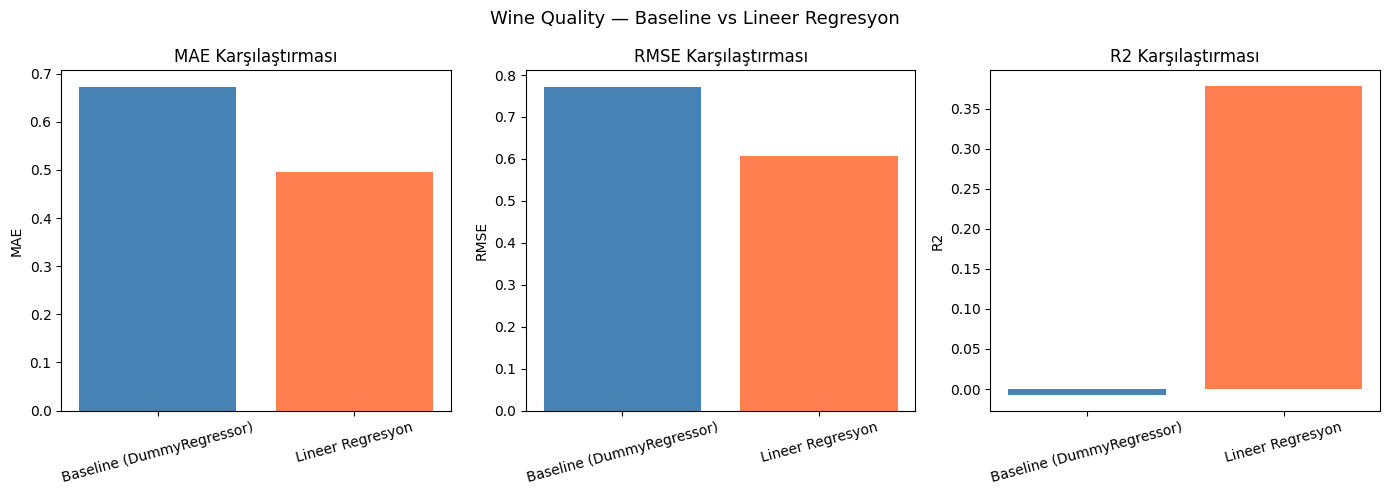

In [ ]:
# Baseline vs Lineer Regresyon metrik karşılaştırması
results_df_2 = pd.DataFrame(results_2)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df_2['model'], results_df_2[metric], color=colors)
    axes[i].set_title(f'{metric} Karşılaştırması')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Wine Quality — Baseline vs Lineer Regresyon', fontsize=13)
plt.tight_layout()
plt.show()

### Değerlendirme Notu

**Wine Quality — Sonuç Yorumu**

Lineer Regresyon, Baseline modele kıyasla MAE'yi %25 oranında düşürmüştür
(0.67 → 0.50) ve R² değeri 0.38 olarak gerçekleşmiştir. Bu, modelin hedef
değişkendeki varyansın yaklaşık %38'ini açıklayabildiğini göstermektedir.

Gerçek vs Tahmin grafiğinde noktaların dikey bantlar halinde toplanması,
hedef değişkenin (kalite skoru) tam sayılardan oluşmasından kaynaklanmaktadır.
Lineer regresyon sürekli değerler ürettiğinden bu veri yapısına tam uyum
sağlayamamaktadır.

Residual plot'taki çizgisel örüntü de aynı nedenle oluşmaktadır — artıklar
rastgele dağılmak yerine belirli bantlarda kümelenmektedir. Bu durum lineer
regresyonun sınırlılığını göstermekle birlikte, baseline ile karşılaştırıldığında
modelin anlamlı bir iyileştirme sağladığı görülmektedir.

# Veri Seti 3: CPU Activity

In [ ]:
# CPU Activity veri seti OpenML'den çekiliyor
cpu = fetch_openml(name='cpu_act', version=1, as_frame=True)

df3 = cpu.frame
print(f"Veri seti boyutu: {df3.shape}")
df3.head()

Veri seti boyutu: (8192, 22)


,lread,lwrite,scall,sread,swrite,fork,exec,rchar,wchar,pgout,...,pgscan,atch,pgin,ppgin,pflt,vflt,runqsz,freemem,freeswap,usr
0,6,2,1036,103,114,1.00,1.00,172076,355965,0.00,...,0.00,0.00,2.00,4.00,73.60,89.00,2.0,6527,1851864,90
1,1,0,2165,205,101,0.40,1.20,43107,44139,4.80,...,181.40,0.20,85.40,88.20,19.40,161.80,3.0,130,1131931,88
2,62,77,3806,258,166,1.40,1.40,492142,268706,4.80,...,79.20,2.20,7.60,12.20,68.00,218.80,5.2,256,1314590,85
3,5,0,4721,256,177,0.99,2.58,524787,174964,14.51,...,189.86,1.99,4.17,24.85,95.63,248.91,1.0,233,972606,81
4,42,55,3949,249,244,2.60,4.60,197289,529200,4.20,...,0.00,1.40,1.80,2.20,219.60,297.20,3.4,331,1013805,79


### Keşifsel Veri Analizi (EDA)

In [ ]:
# Veri setinin genel bilgileri
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8192 entries, 0 to 8191
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   lread     8192 non-null   int64  
 1   lwrite    8192 non-null   int64  
 2   scall     8192 non-null   int64  
 3   sread     8192 non-null   int64  
 4   swrite    8192 non-null   int64  
 5   fork      8192 non-null   float64
 6   exec      8192 non-null   float64
 7   rchar     8192 non-null   int64  
 8   wchar     8192 non-null   int64  
 9   pgout     8192 non-null   float64
 10  ppgout    8192 non-null   float64
 11  pgfree    8192 non-null   float64
 12  pgscan    8192 non-null   float64
 13  atch      8192 non-null   float64
 14  pgin      8192 non-null   float64
 15  ppgin     8192 non-null   float64
 16  pflt      8192 non-null   float64
 17  vflt      8192 non-null   float64
 18  runqsz    8192 non-null   float64
 19  freemem   8192 non-null   int64  
 20  freeswap  8192 non-null   int6

In [ ]:
# Temel istatistiksel özet
df3.describe()

,lread,lwrite,scall,sread,swrite,fork,exec,rchar,wchar,pgout,...,pgscan,atch,pgin,ppgin,pflt,vflt,runqsz,freemem,freeswap,usr
count,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8.192000e+03,8.192000e+03,8192.000000,...,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8.192000e+03,8192.000000
mean,19.559692,13.106201,2306.318237,210.479980,150.058228,1.884554,2.791998,1.970137e+05,9.589829e+04,2.285317,...,21.526849,1.127505,8.277960,12.388586,109.793799,185.315796,19.630676,1763.456299,1.328126e+06,83.968872
std,53.353799,29.891726,1633.617322,198.980146,160.478980,2.479493,5.212456,2.394808e+05,1.407569e+05,5.307038,...,71.141340,5.708347,13.874978,22.281318,114.419221,191.000603,125.742085,2482.104511,4.220194e+05,18.401905
min,0.000000,0.000000,109.000000,6.000000,7.000000,0.000000,0.000000,2.780000e+02,1.498000e+03,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,1.000000,55.000000,2.000000e+00,0.000000
25%,2.000000,0.000000,1012.000000,86.000000,63.000000,0.400000,0.200000,3.386425e+04,2.293550e+04,0.000000,...,0.000000,0.000000,0.600000,0.600000,25.000000,45.400000,1.200000,231.000000,1.042624e+06,81.000000
50%,7.000000,1.000000,2051.500000,166.000000,117.000000,0.800000,1.200000,1.247795e+05,4.662000e+04,0.000000,...,0.000000,0.000000,2.800000,3.800000,63.800000,120.400000,2.000000,579.000000,1.289290e+06,89.000000
75%,20.000000,10.000000,3317.250000,279.000000,185.000000,2.200000,2.800000,2.676692e+05,1.061480e+05,2.400000,...,0.000000,0.600000,9.765000,13.800000,159.600000,251.800000,3.000000,2002.250000,1.730380e+06,94.000000
max,1845.000000,575.000000,12493.000000,5318.000000,5456.000000,20.120000,59.560000,2.526649e+06,1.801623e+06,81.440000,...,1237.000000,211.580000,141.200000,292.610000,899.800000,1365.000000,2823.000000,12027.000000,2.243187e+06,99.000000


In [ ]:
# Eksik değerlerin kontrolü
missing3 = df3.isnull().sum()
print("Eksik değer sayıları:")
print(missing3[missing3 > 0])
print(f"\nToplam eksik değer: {df3.isnull().sum().sum()}")

Eksik değer sayıları:
Series([], dtype: int64)

Toplam eksik değer: 0


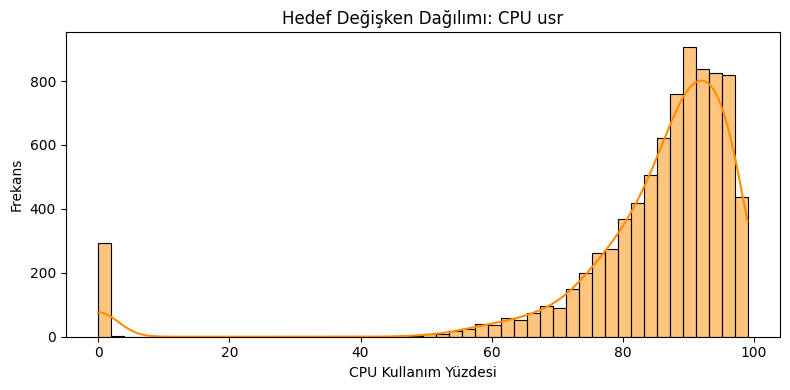

In [ ]:
# Hedef değişkenin dağılımı (CPU kullanım yüzdesi)
plt.figure(figsize=(8, 4))
sns.histplot(df3['usr'], bins=50, kde=True, color='darkorange')
plt.title('Hedef Değişken Dağılımı: CPU usr')
plt.xlabel('CPU Kullanım Yüzdesi')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

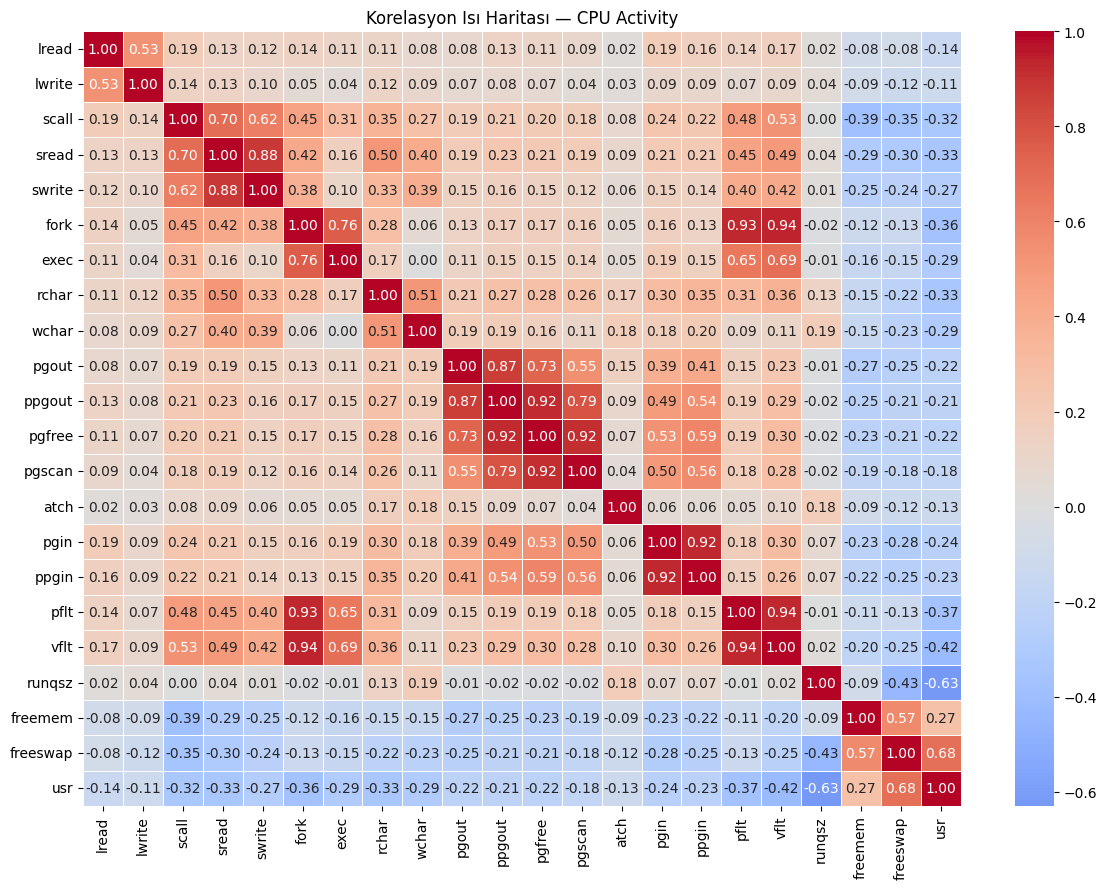

In [ ]:
# Sayısal değişkenler arası korelasyon ısı haritası
numerical_df3 = df3.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 9))
sns.heatmap(numerical_df3.corr(), cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5)
plt.title('Korelasyon Isı Haritası — CPU Activity')
plt.tight_layout()
plt.show()

### Veri Ön İşleme

In [ ]:
# Eksik değer yoksa bilgi veriliyor, varsa medyan ile dolduruluyor
if df3.isnull().sum().sum() == 0:
    print(" Eksik değer bulunmuyor.")
else:
    df3 = df3.fillna(df3.median())
    print(" Eksik değerler medyan ile dolduruldu.")

 Eksik değer bulunmuyor.


In [ ]:
# Hedef değişkendeki aykırı değerler IQR yöntemiyle tespit ediliyor
Q1_c = df3['usr'].quantile(0.25)
Q3_c = df3['usr'].quantile(0.75)
IQR_c = Q3_c - Q1_c

lower_c = Q1_c - 1.5 * IQR_c
upper_c = Q3_c + 1.5 * IQR_c

outliers_c = df3[(df3['usr'] < lower_c) | (df3['usr'] > upper_c)]
print(f"Tespit edilen aykırı değer sayısı: {len(outliers_c)}")

Tespit edilen aykırı değer sayısı: 430


In [ ]:
# Aykırı değerler veri setinden çıkarılıyor
df3 = df3[(df3['usr'] >= lower_c) & (df3['usr'] <= upper_c)]
print(f"Temizleme sonrası veri boyutu: {df3.shape}")

Temizleme sonrası veri boyutu: (7762, 22)


In [ ]:
# Özellikler (X) ve hedef değişken (y) ayrılıyor
X3 = df3.drop(columns=['usr'])
y3 = df3['usr']

print(f"X boyutu: {X3.shape}")
print(f"y boyutu: {y3.shape}")

X boyutu: (7762, 21)
y boyutu: (7762,)


#### Train/Test Split

In [ ]:
# Veri %80 eğitim, %20 test olarak ayrılıyor
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

print(f"Eğitim seti: {X3_train.shape}")
print(f"Test seti: {X3_test.shape}")

Eğitim seti: (6209, 21)
Test seti: (1553, 21)


In [ ]:
# Özellikler StandardScaler ile ölçeklendiriliyor
scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

print("Ölçeklendirme tamamlandı.")

Ölçeklendirme tamamlandı.


### Model Eğitimi

In [ ]:
# Baseline model olarak DummyRegressor kullanılıyor
dummy3 = DummyRegressor(strategy='mean')
dummy3.fit(X3_train_scaled, y3_train)
y3_pred_dummy = dummy3.predict(X3_test_scaled)

print(" Baseline model eğitildi.")

 Baseline model eğitildi.


In [ ]:
# Lineer regresyon modeli eğitiliyor
lr3 = LinearRegression()
lr3.fit(X3_train_scaled, y3_train)
y3_pred_lr = lr3.predict(X3_test_scaled)

print(" Lineer regresyon modeli eğitildi.")

 Lineer regresyon modeli eğitildi.


In [ ]:
# Baseline ve lineer regresyon metrikleri hesaplanıyor
results_3 = []
results_3.append(evaluate_model(y3_test, y3_pred_dummy, "Baseline (DummyRegressor)"))
results_3.append(evaluate_model(y3_test, y3_pred_lr, "Lineer Regresyon"))

  Baseline (DummyRegressor)
  MAE  : 6.38
  RMSE : 8.02
  R²   : -0.0022

  Lineer Regresyon
  MAE  : 1.97
  RMSE : 2.76
  R²   : 0.8814



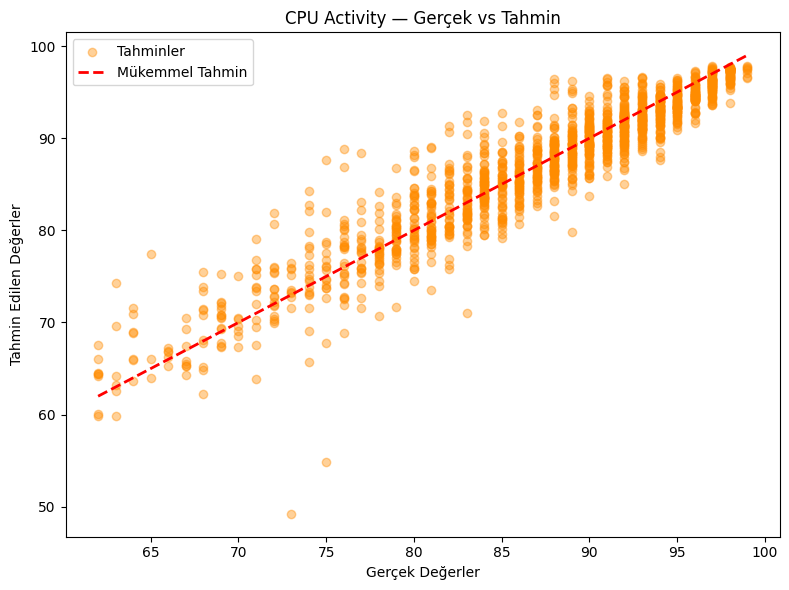

In [ ]:
# Gerçek vs tahmin edilen değerler karşılaştırması
plt.figure(figsize=(8, 6))
plt.scatter(y3_test, y3_pred_lr, alpha=0.4, color='darkorange', label='Tahminler')
plt.plot([y3_test.min(), y3_test.max()], [y3_test.min(), y3_test.max()],
         'r--', linewidth=2, label='Mükemmel Tahmin')
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('CPU Activity — Gerçek vs Tahmin')
plt.legend()
plt.tight_layout()
plt.show()

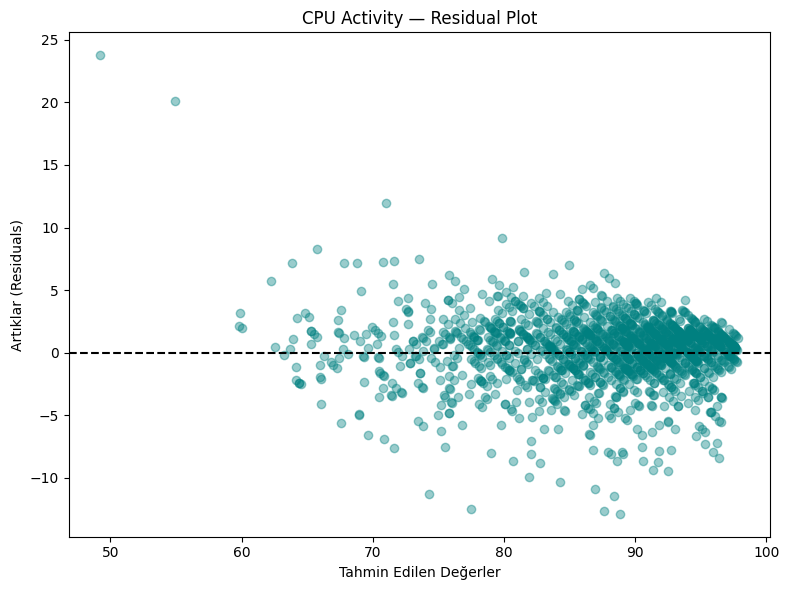

In [ ]:
# Artık (residual) değerlerin dağılımı inceleniyor
residuals3 = y3_test - y3_pred_lr

plt.figure(figsize=(8, 6))
plt.scatter(y3_pred_lr, residuals3, alpha=0.4, color='teal')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Artıklar (Residuals)')
plt.title('CPU Activity — Residual Plot')
plt.tight_layout()
plt.show()

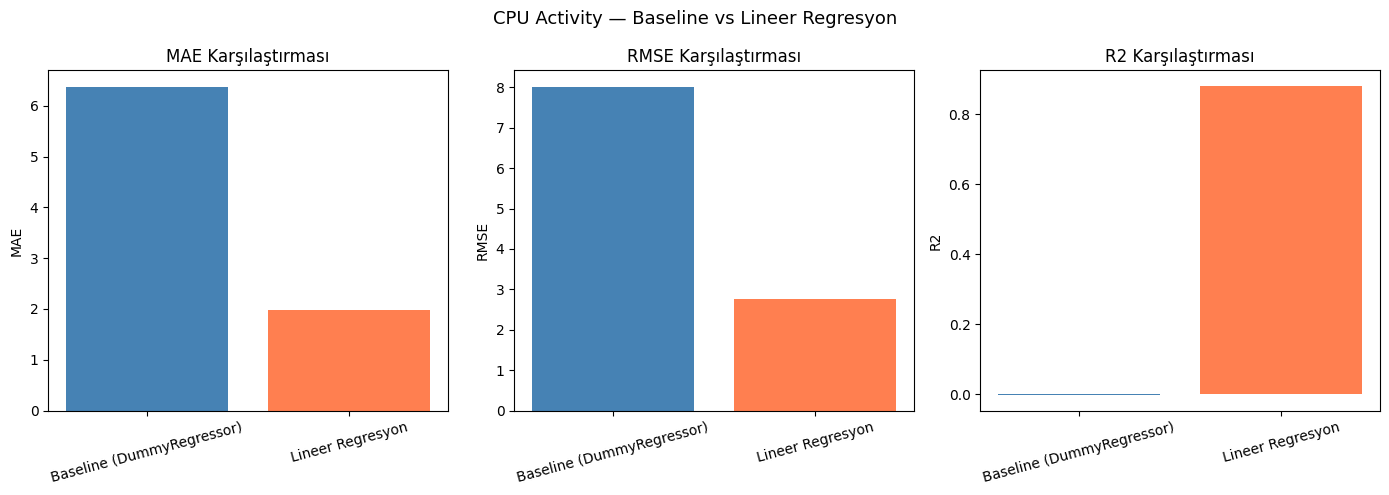

In [ ]:
# Baseline vs Lineer Regresyon metrik karşılaştırması
results_df_3 = pd.DataFrame(results_3)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df_3['model'], results_df_3[metric], color=colors)
    axes[i].set_title(f'{metric} Karşılaştırması')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('CPU Activity — Baseline vs Lineer Regresyon', fontsize=13)
plt.tight_layout()
plt.show()

### Değerlendirme Notu

**CPU Activity — Sonuç Yorumu**

Lineer Regresyon bu veri setinde oldukça güçlü bir performans sergilemiştir.
R² değeri 0.88 olarak gerçekleşmiş, yani model hedef değişkendeki varyansın
%88'ini açıklayabilmektedir. MAE baseline'a kıyasla %69 oranında düşmüştür
(6.38 → 1.97), RMSE ise 8.02'den 2.76'ya gerilemiştir.

Gerçek vs Tahmin grafiğinde noktaların kırmızı çizgiye yakın ve düzenli
dağıldığı görülmektedir. Bu, CPU aktivitesi ile özellikler arasında güçlü
bir doğrusal ilişki bulunduğuna işaret etmektedir.

Residual plot'ta artıkların genel olarak sıfır etrafında rastgele dağıldığı,
ancak düşük tahmin değerlerinde birkaç aykırı artık bulunduğu gözlemlenmektedir.
Bu durum modelin yüksek CPU kullanım bölgelerinde daha tutarlı çalıştığını
göstermektedir.

# Genel Karşılaştırma

In [ ]:
# Tüm veri setlerinin lineer regresyon sonuçları tek tabloda özetleniyor
summary = pd.DataFrame({
    'Veri Seti': ['California Housing', 'Wine Quality', 'CPU Activity'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y2_test, y2_pred_lr),
        mean_absolute_error(y3_test, y3_pred_lr)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y2_test, y2_pred_lr)),
        np.sqrt(mean_squared_error(y3_test, y3_pred_lr))
    ],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y2_test, y2_pred_lr),
        r2_score(y3_test, y3_pred_lr)
    ]
})

summary = summary.round(4)
print(summary.to_string(index=False))

         Veri Seti        MAE       RMSE     R²
California Housing 17308.5030 54916.6034 0.0519
      Wine Quality     0.4956     0.6067 0.3787
      CPU Activity     1.9726     2.7588 0.8814


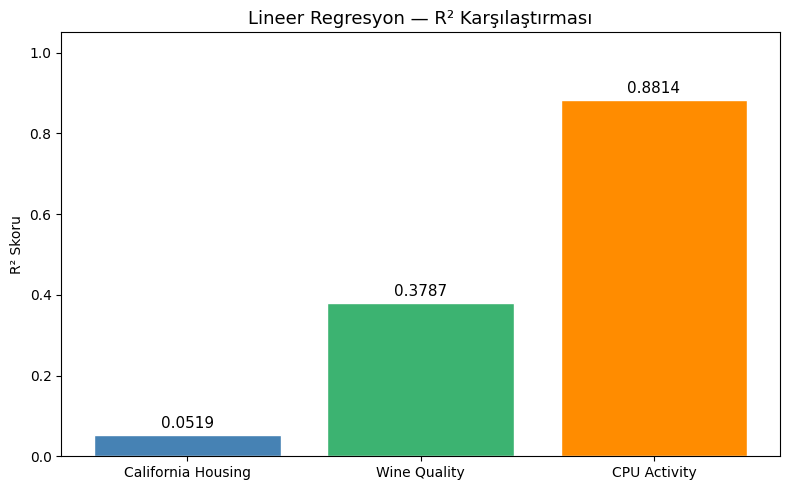

In [ ]:
# Üç veri setinin R² değerleri karşılaştırılıyor
plt.figure(figsize=(8, 5))
colors = ['steelblue', 'mediumseagreen', 'darkorange']
bars = plt.bar(summary['Veri Seti'], summary['R²'], color=colors, edgecolor='white')

for bar, val in zip(bars, summary['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.title('Lineer Regresyon — R² Karşılaştırması', fontsize=13)
plt.ylabel('R² Skoru')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

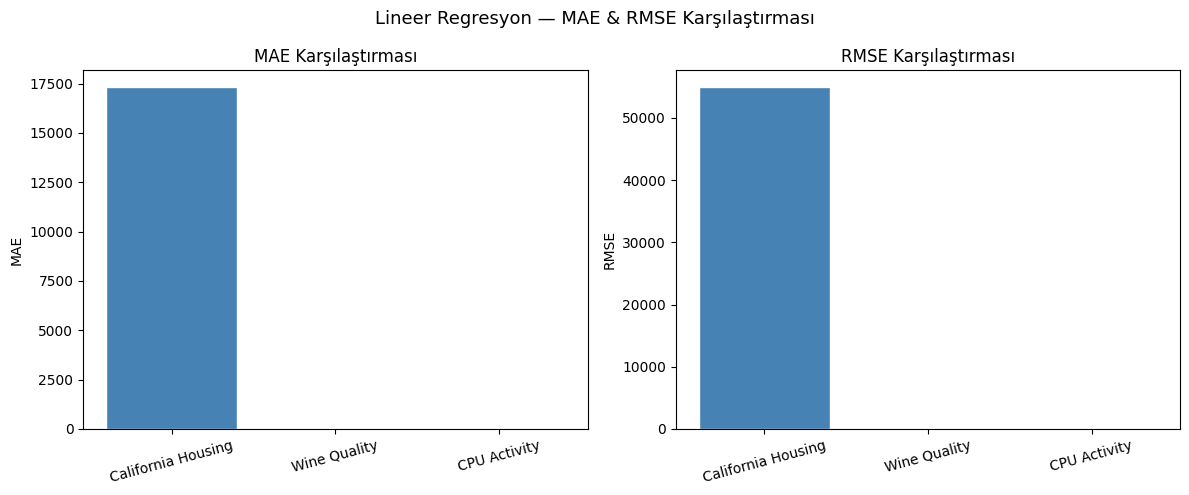

In [ ]:
# Üç veri setinin MAE ve RMSE değerleri karşılaştırılıyor
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(summary['Veri Seti'], summary['MAE'], color=colors, edgecolor='white')
axes[0].set_title('MAE Karşılaştırması')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(summary['Veri Seti'], summary['RMSE'], color=colors, edgecolor='white')
axes[1].set_title('RMSE Karşılaştırması')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Lineer Regresyon — MAE & RMSE Karşılaştırması', fontsize=13)
plt.tight_layout()
plt.show()

Bu çalışmada üç farklı veri seti üzerinde lineer regresyon modeli uygulanmış
ve her model DummyRegressor baseline'ı ile karşılaştırılmıştır.

- **CPU Activity** en yüksek performansı sergilemiştir (R² = 0.88).
  Özellikler ile hedef değişken arasındaki güçlü doğrusal ilişki
  lineer regresyonun bu veri setine iyi uyum sağlamasını açıklamaktadır.

- **Wine Quality** orta düzey bir performans göstermiştir (R² = 0.38).
  Hedef değişkenin tam sayılardan oluşması modelin sürekli tahminler
  üretmesini kısıtlamıştır.

- **California Housing** en düşük performansı vermiştir (R² = 0.05).
  One-hot encoding sonrası özellik boyutunun büyük ölçüde artması
  lineer regresyonun bu veri setinde zorlanmasına yol açmıştır.

Tüm veri setlerinde lineer regresyon, baseline modeli anlamlı ölçüde
geride bırakmıştır. Bu sonuçlar, lineer regresyonun veri yapısına
bağlı olarak farklı performans sergilediğini ortaya koymaktadır.